## Autoencoders in Machine Learning


Autoencoders are neural networks that compress input data into a smaller representation and then reconstruct it, helping the model learn important patterns efficiently. Their key uses include:

* Helps remove unwanted noise from data and improve quality
* Identifies unusual patterns or anomalies in data
* Extracts important features for better model performance

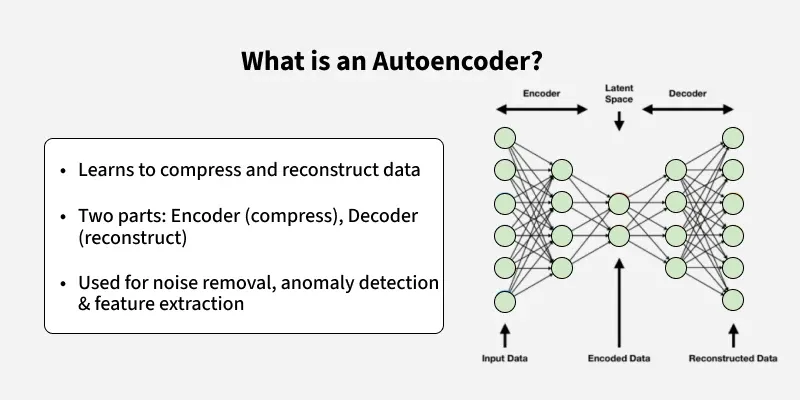

## Architecture of Autoencoder

An autoencoder’s architecture consists of three main components that work together to compress and then reconstruct data which are as follows:

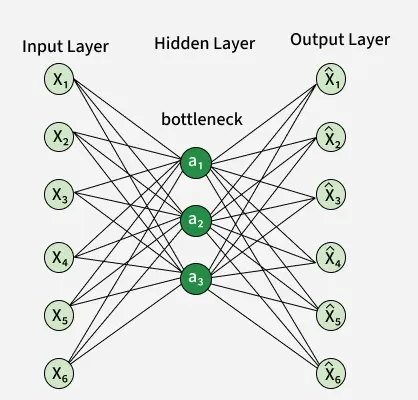

### 1. Encoder

It compress the input data into a smaller, more manageable form by reducing its dimensionality while preserving important information. It has three layers which are:

* **Input Layer:** Here the original data enters the network. It can be images, text features or any other structured data.
* **Hidden Layers:** These layers perform a series of transformations on the input data. Each hidden layer applies weights and activation functions to capture important patterns, progressively reducing the data's size and complexity.
* **Output (Latent Space):** The encoder outputs a compressed vector known as the latent representation or encoding. This vector captures the important features of the input data in a condensed form helps in filtering out noise and redundancies.

### 2. Bottleneck (Latent Space)

The bottleneck is the smallest layer in the network that holds a compressed representation of the input data. It forces the model to keep only the most important features, helping it learn key patterns and improve generalization.

### 3. Decoder

It is responsible for taking the compressed representation from the latent space and reconstructing it back into the original data form.

* **Hidden Layers:** Progressively expand the latent vector back into a higher-dimensional space. Through successive transformations decoder attempts to restore the original data shape and details
* **Output Layer:** Produces the reconstructed output which aims to closely resemble the original input. The quality of reconstruction depends on how well the encoder-decoder pair can minimize the difference between the input and output during training.

## Loss Function in Autoencoder Training

During training an autoencoder’s goal is to minimize the reconstruction loss which measures how different the reconstructed output is from the original input. The choice of loss function depends on the type of data being processed:

* **Mean Squared Error (MSE):** Commonly used for continuous data. It measures the average squared differences between the input and the reconstructed data.
* **Binary Cross-Entropy:** Used for binary data (0 or 1 values). It calculates the difference in probability between the original and reconstructed output.
During training the network updates its weights using backpropagation to minimize this reconstruction loss. By doing this it learns to extract and retain the most important features of the input data which are encoded in the latent space.

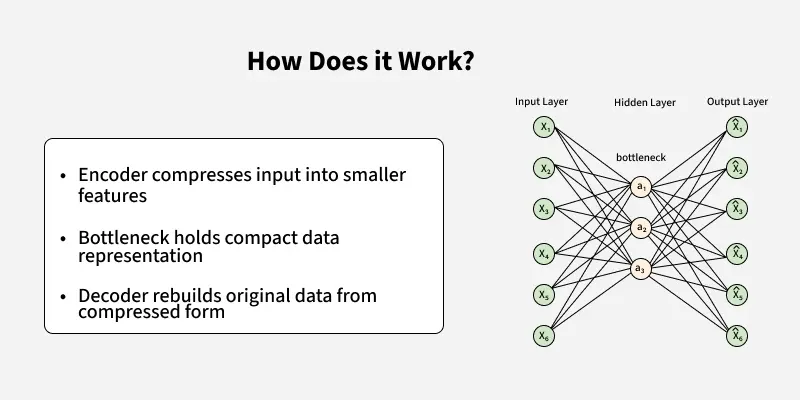

## Types of Autoencoders

There are several types of autoencoders, each designed for specific tasks and data types:

### 1. Denoising Autoencoder
Denoising autoencoders are designed to remove noise from data. During training, they take a corrupted version of the input data and learn to reconstruct the original, clean data. This helps the model learn robust features that are less sensitive to noise, making it useful for tasks like image denoising and improving data quality.

### 2. Variational Autoencoder (VAE)
Variational autoencoders are a type of generative model that learns to represent data in a continuous latent space. They use a probabilistic approach to encode data, allowing for the generation of new data samples by sampling from the latent space. VAEs are commonly used in tasks like image generation, anomaly detection, and representation learning.

### 3. Convolutional Autoencoder
Convolutional autoencoders are designed for image data and use convolutional layers in both the encoder and decoder. They are effective at capturing spatial hierarchies in images, making them suitable for tasks like image compression, denoising, and feature extraction.

### 4. Recurrent Autoencoder
Recurrent autoencoders are designed for sequential data, such as time series or natural language. They use recurrent layers (like LSTM or GRU) to capture temporal dependencies in the data. They are useful for tasks like sequence prediction, anomaly detection in time series, and natural language processing.

### 5. Sparse Autoencoder
Sparse autoencoders are designed to learn a sparse representation of the input data. They include a sparsity constraint in the loss function, encouraging the model to activate only a small number of neurons in   the latent space. This can help the model learn more meaningful features and improve interpretability.

### 6. Contractive Autoencoder
Contractive autoencoders are designed to learn robust features by adding a regularization term to the loss function that encourages the model to be less sensitive to small changes in the input data. This helps the model learn more stable and invariant features, making it useful for tasks like anomaly detection and representation learning. 



## Implementation

We will create a simple autoencoder with two Dense layers:

* Encoder that compresses images into a 64-dimensional latent vector.
*  Decoder that reconstructs the original image from this compressed form.

### Step 1: Import necessary libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, losses
from tensorflow.keras.models import Model
from keras.datasets import mnist

### Step 2: Load the MNIST dataset

In [2]:
(x_train, _), (x_test, _) = mnist.load_data()

x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test = np.reshape(x_test, (len(x_test), 28, 28, 1))

### Step 3: Define a basic Autoencoder

Creating a simple autoencoder class with an encoder and decoder using Keras Sequential model.

* **layers.Input(shape=(28, 28, 1)):** Input layer expecting grayscale images of size 28x28.
* **layers.Dense(latent_dimensions, activation='relu'):** Dense layer that compresses the input to the latent space using ReLU activation.
* **layers.Dense(28 * 28, activation='sigmoid'):** Dense layer that expands the latent vector back to the original image size with sigmoid activation.

In [3]:
class SimpleAutoencoder(Model):
    def __init__(self, latent_dimensions):
        super(SimpleAutoencoder, self).__init__()
        self.encoder = tf.keras.Sequential([
            layers.Input(shape=(28, 28, 1)),
            layers.Flatten(),
            layers.Dense(latent_dimensions, activation='relu'),
        ])
        self.decoder = tf.keras.Sequential([
            layers.Dense(28 * 28, activation='sigmoid'),
            layers.Reshape((28, 28, 1))
        ])
    def call(self, input_data):
        encoded = self.encoder(input_data)
        decoded = self.decoder(encoded)
        return decoded

### Step 4: Compiling and Fitting Autoencoder

Here we compile the model using Adam optimizer and Mean Squared Error loss also we train for 10 epochs with batch size 256.

* **latent_dimensions = 64:** Sets the size of the compressed latent space to 64.

In [4]:
latent_dimensions = 64
autoencoder = SimpleAutoencoder(latent_dimensions)
autoencoder.compile(optimizer='adam', loss=losses.MeanSquaredError())
autoencoder.fit(x_train, x_train, epochs=10, batch_size=256, shuffle=True, validation_data=(x_test, x_test))

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0591 - val_loss: 0.0320
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0262 - val_loss: 0.0211
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0184 - val_loss: 0.0154
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0139 - val_loss: 0.0118
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0109 - val_loss: 0.0094
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0088 - val_loss: 0.0078
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0074 - val_loss: 0.0067
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.0065 - val_loss: 0.0059
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.0058 - val_loss: 0.0054
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0054 - val_loss: 0.0050


### Step 5: Visualize original and reconstructed data

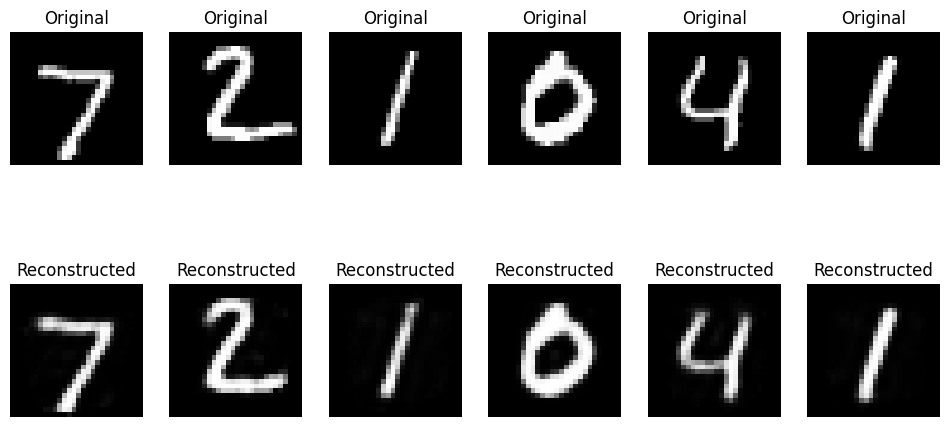

In [5]:
encoded_imgs = autoencoder.encoder(x_test).numpy()
decoded_imgs = autoencoder.decoder(encoded_imgs).numpy()

n = 6
plt.figure(figsize=(12, 6))
for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    plt.title("Reconstructed")
    plt.axis('off')

plt.show()

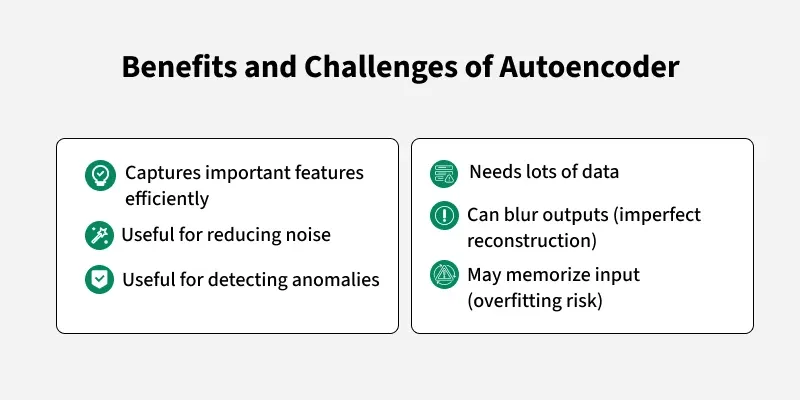

                                                       How Autoencoders works ?             


## How Autoencoders works ?


Autoencoders is used for tasks like dimensionality reduction, anomaly detection and feature extraction. The goal of an autoencoder is to to compress data into a compact form and then reconstruct it to closely match the original input. The model trains by minimizing reconstruction error using loss functions.

### Understanding Working of Autoencoders

Autoencoder has two main parts:

* **Encoder:** It takes an input sample and compresses it into a lower-dimensional representation called the latent space or latent code
* **Decoder:** It then reconstructs the original input from this compressed representation producing 

The goal is for the autoencoder to learn a function that maps input data to a compressed space and then back to its original form. This is achieved by training the network to minimize the difference between the input and its reconstructed output.

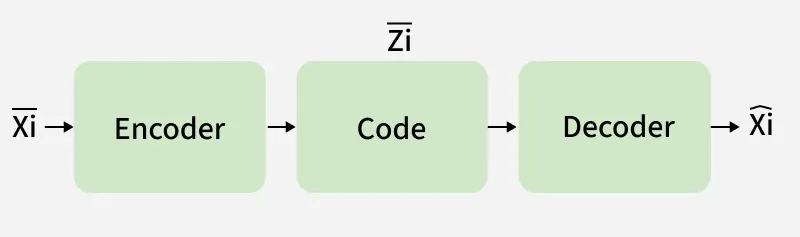

### Cost Function and Optimization

The cost function measures how well the autoencoder performs. The objective is to minimize the difference between the input sample 
 and the reconstructed output measured using the Mean Squared Error (MSE) which is defined as:
MSE = (1/n) * Σ(x - x')^2
Where:
* **x:** Original input data
* **x':** Reconstructed output from the autoencoder
* **n:** Number of samples in the dataset

## Variational Autoencoder

A Variational Autoencoder (VAE) is a type of generative model that learns to represent data in a continuous latent space. It uses a probabilistic approach to encode data, allowing for the generation of new data samples by sampling from the latent space. VAEs are commonly used in tasks like image generation, anomaly detection, and representation learning.



## Implementing a Deep Convolutional Autoencoder

We’ll build a deep convolutional autoencoder using TensorFlow and train it on the Olivetti Faces dataset which contains 400 grayscale face images (64×64 pixels each). The autoencoder will learn to compress and then reconstruct these images.

### Step 1: Loading the Dataset

In [6]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.datasets import fetch_olivetti_faces

faces = fetch_olivetti_faces(shuffle=True, random_state=1000)
X_train = faces['images']

downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to C:\Users\PANDIT JI\scikit_learn_data


### Step 2: Resizing the Images
Now to increase the speed of our computation we will resize them to 32 × 32. This will also help avoid any memory issues. We may lose a minor visual precision. Note that we can skip this if we have high computational resources.  

In [7]:
width, height = 32, 32
X_train = tf.image.resize(X_train[..., np.newaxis], (width, height))

### Step 3: Defining Training Parameters

Now let's set up training parameters

In [8]:
nb_epochs = 100
batch_size = 50
code_length = 256

### Step 4: Adding Noise to Images
To make the autoencoder more robust we add Gaussian noise to the images. This will be the input to the autoencoder during training.

In [9]:
def add_noise(images, noise_factor=0.2):
    noisy_images = images + noise_factor * tf.random.normal(shape=images.shape)
    return tf.clip_by_value(noisy_images, 0.0, 1.0)

### Step 5: Define the Autoencoder

* **Conv2D:** Extracts features from the image.
* **Flatten:** Converts the image into a 1D vector.
* **Dense:** Fully connected layer for compression.
* **Conv2DTranspose:** Up sampling layers to reconstruct the image.
* **sigmoid:** Keeps pixel values between 0 and 1.

In [10]:
def build_autoencoder(input_shape, code_length=256):
    input_img = keras.Input(shape=input_shape)

    x = layers.Conv2D(16, (3, 3), strides=(2, 2), activation='relu', padding='same')(input_img)
    x = layers.Conv2D(32, (3, 3), strides=(1, 1), activation='relu', padding='same')(x)
    x = layers.Conv2D(64, (3, 3), strides=(1, 1), activation='relu', padding='same')(x)
    x = layers.Conv2D(128, (3, 3), strides=(1, 1), activation='relu', padding='same')(x)
    x = layers.Flatten()(x)
    code_layer = layers.Dense(code_length, activation='sigmoid')(x)

    x = layers.Dense((width // 2) * (height // 2) * 128, activation='relu')(code_layer)
    x = layers.Reshape((width // 2, height // 2, 128))(x)
    x = layers.Conv2DTranspose(128, (3, 3), strides=(2, 2), activation='relu', padding='same')(x)
    x = layers.Conv2DTranspose(64, (3, 3), strides=(1, 1), activation='relu', padding='same')(x)
    x = layers.Conv2DTranspose(32, (3, 3), strides=(1, 1), activation='relu', padding='same')(x)
    output_img = layers.Conv2DTranspose(1, (3, 3), strides=(1, 1), activation='sigmoid', padding='same')(x)

    autoencoder = keras.Model(input_img, output_img)
    return autoencoder

### Step 6: Compile the Model
Now we define the loss function (MSE) and the optimizer (Adam).

In [11]:
input_shape = (width, height, 1)
autoencoder = build_autoencoder(input_shape)

autoencoder.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss='mse')

### Step 7: Train the Model
We train the model to reconstruct noisy images and the model learns how to remove noise from images during training.

In [12]:
X_train_noisy = add_noise(X_train)
autoencoder.fit(X_train_noisy, X_train, epochs=nb_epochs, batch_size=batch_size, shuffle=True)

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 486ms/step - loss: 0.0254
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 483ms/step - loss: 0.0214
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 532ms/step - loss: 0.0204
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 631ms/step - loss: 0.0195
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 610ms/step - loss: 0.0186
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 553ms/step - loss: 0.0182
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 694ms/step - loss: 0.0179
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 784ms/step - loss: 0.0172
Epoch 9/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 11s 845ms/step - loss: 0.0163
Epoch 10/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 977ms/step - loss: 0.0156
Epoch 11/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 612ms/step - loss: 0.0152
Epoch 12/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 658ms/step - loss: 0.0146
Epoch 13/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 11s 769ms/step - loss: 0.0139
Epoch 14/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - loss: 0.0125
Epoch 15/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 642ms/step - loss: 0.0119
Epoch

### Step 8: Show Original and Reconstructed Images
Finally we display the original and reconstructed images.

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 556ms/step


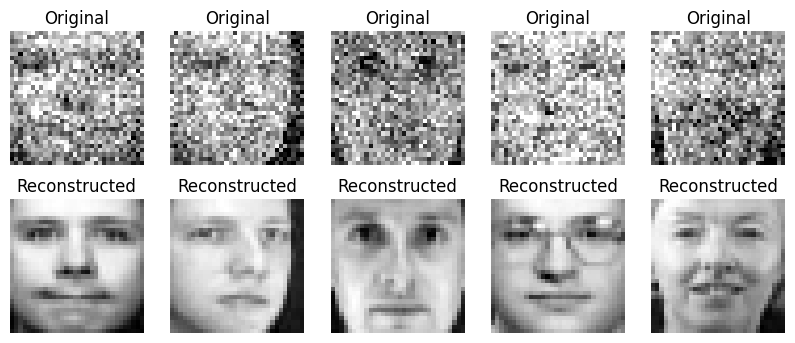

In [13]:
def show_images(original, reconstructed, num=5):
    plt.figure(figsize=(10, 4))
    for i in range(num):
        plt.subplot(2, num, i + 1)
        plt.imshow(original[i].squeeze(), cmap='gray')
        plt.axis('off')
        plt.title("Original")

        plt.subplot(2, num, num + i + 1)
        plt.imshow(reconstructed[i].squeeze(), cmap='gray')
        plt.axis('off')
        plt.title("Reconstructed")

    plt.show()

X_train_noisy = X_train_noisy.numpy() if isinstance(X_train_noisy, tf.Tensor) else X_train_noisy

reconstructed_images = autoencoder.predict(X_train_noisy[:5])
show_images(X_train_noisy, reconstructed_images)

                                                           Types of Autoencoders                               


## Types of Autoencoders


Autoencoders are a type of neural network designed to learn efficient data representations. They work by compressing input data into a smaller, dense format called the latent space using an encoder and then reconstructing the original input from this compressed form using a decoder. This makes autoencoders useful for tasks such as dimensionality reduction, feature extraction and noise removal.

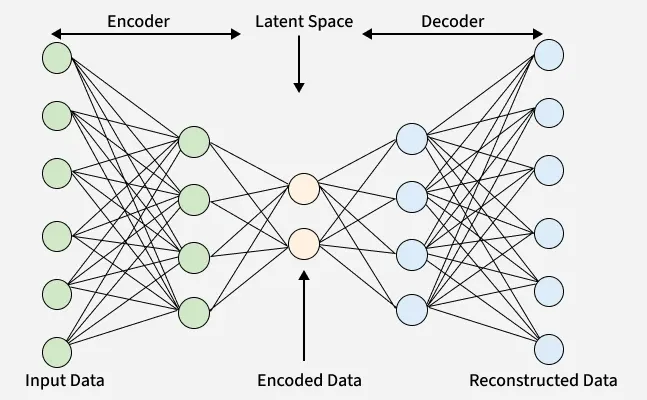

Let’s see common types of autoencoders which are designed with unique features to handle specific challenges and tasks in data representation and learning.

## 1. Vanilla Autoencoder

* Vanilla Autoencoder are the simplest form used for unsupervised learning tasks. They consist of two main parts an encoder that compresses the input data into a smaller, dense representation and a decoder that reconstructs the original input from this compressed form.
* Training minimizes reconstruction error which measures the difference between input and output. This optimization is done via backpropagation which helps in updating the network weights to improve reconstruction accuracy.
* They are foundational models helps in serving as building blocks for more complex variants.

## Applications of Vanilla Autoencoder
* Dimensionality Reduction: Compressing high-dimensional data into a lower-dimensional latent space while preserving important features.
* Feature Extraction: Learning useful features from data for tasks like classification or clustering.
* Data Denoising: Removing noise from data by learning to reconstruct clean inputs from noisy versions



29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 2us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 16s 1us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 9us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 3s 1us/step
Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.4117 - val_loss: 0.3416
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.3275 - val_loss: 0.3205
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.3124 - val_loss: 0.3085
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.3021 - val_loss: 0.3005
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.2957 - val_loss: 0.2955
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.2915 - val_loss: 0.2922
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.2889 - val_loss: 0.2901
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.2872 - val_loss: 0.2887
Epoch 9/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.2860 - val_loss: 0.2881
Epoch 10/50
235/235 ━━━━━━━━━━━━━━━━

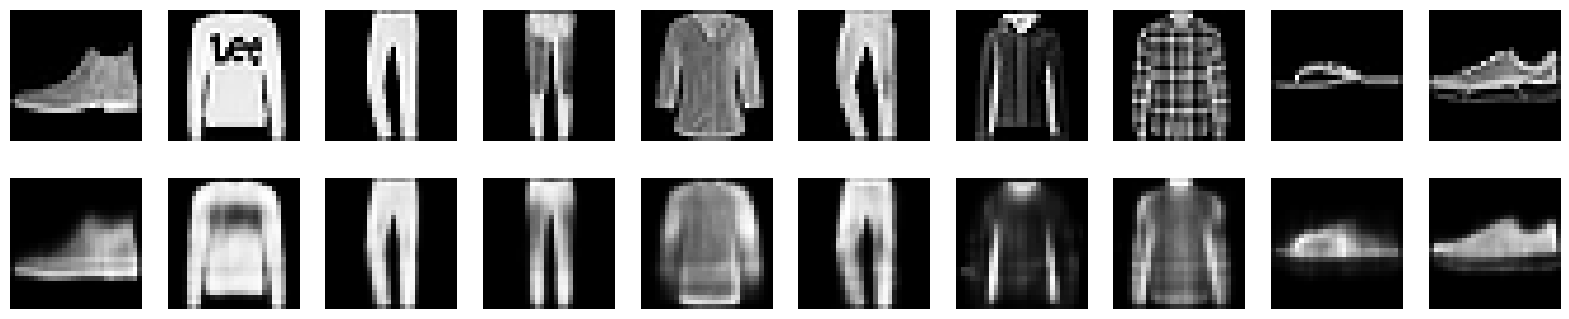

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist

(x_train, _), (x_test, _) = fashion_mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

x_train_flat = x_train.reshape(len(x_train), 784)
x_test_flat = x_test.reshape(len(x_test), 784)

n = 10 
encoding_dim = 32
input_img = tf.keras.Input(shape=(784,))
encoded = tf.keras.layers.Dense(encoding_dim, activation='relu')(input_img)
decoded = tf.keras.layers.Dense(784, activation='sigmoid')(encoded)

autoencoder = tf.keras.Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

autoencoder.fit(x_train_flat, x_train_flat,
                epochs=50,
                batch_size=256,
                shuffle=True,
                validation_data=(x_test_flat, x_test_flat))

decoded_imgs = autoencoder.predict(x_test_flat)

plt.figure(figsize=(20, 4))
for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test_flat[i].reshape(28, 28), cmap='gray')
    ax.axis('off')

    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    ax.axis('off')
plt.show()

## 2. Sparse Autoencoder
* Sparse Autoencoders are designed to learn a sparse representation of the input data. They include a sparsity constraint in the loss function, encouraging the model to activate only a small number of neurons in the latent space. This can help the model learn more meaningful features and improve interpretability.
* The sparsity constraint is typically implemented using a regularization term such as L1 regularization or Kullback-Leibler divergence which penalizes the activation of neurons in the latent space, encouraging the model to use only a few neurons to represent the input data. This can lead to more efficient and interpretable representations, as the model focuses on learning the most important features of the data while ignoring less relevant information.   

## Applications of Sparse Autoencoder
* Feature Selection: Identifying the most important features in the data by encouraging sparsity in the latent representation.
* Anomaly Detection: Detecting unusual patterns in data by learning a sparse representation that captures normal patterns while ignoring anomalies.
* Interpretability: Providing more interpretable representations by encouraging the model to focus on a few key features rather than using all available neurons in the latent space.



Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.6072 - val_loss: 0.4751
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.4535 - val_loss: 0.4428
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.4298 - val_loss: 0.4220
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.4142 - val_loss: 0.4105
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.4042 - val_loss: 0.4018
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.3963 - val_loss: 0.3945
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.3901 - val_loss: 0.3891
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.3854 - val_loss: 0.3853
Epoch 9/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.3823 - val_loss: 0.3825
Epoch 10/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.3801 - val_loss: 0.3809
Epoch 11/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.3786 - val_loss: 0.3793
Epoch 12/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step

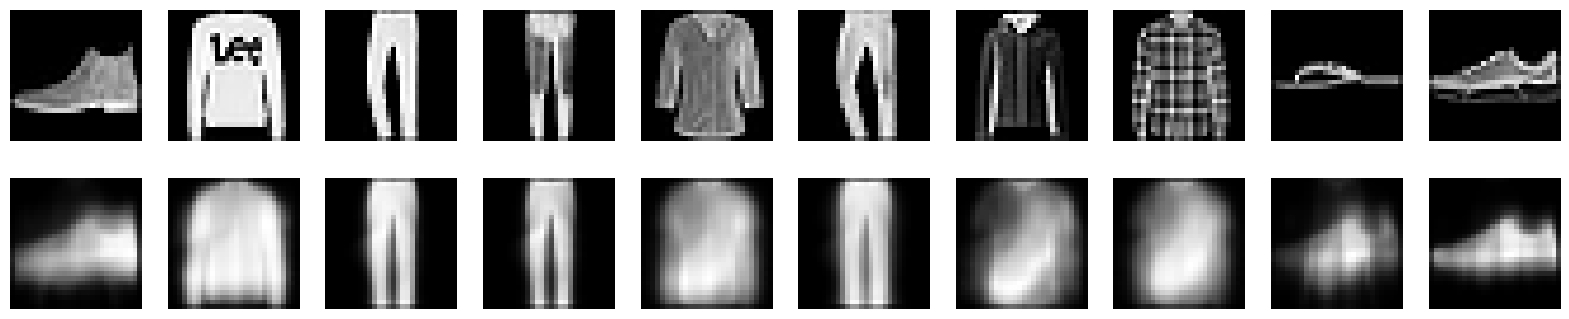

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist

(x_train, _), (x_test, _) = fashion_mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

x_train_flat = x_train.reshape(len(x_train), 784)
x_test_flat = x_test.reshape(len(x_test), 784)

n = 10 
encoding_dim = 32
input_img = tf.keras.Input(shape=(784,))
encoded = tf.keras.layers.Dense(encoding_dim, activation='relu',
                                activity_regularizer=tf.keras.regularizers.l1(1e-5))(input_img)
decoded = tf.keras.layers.Dense(784, activation='sigmoid')(encoded)

sparse_autoencoder = tf.keras.Model(input_img, decoded)
sparse_autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

sparse_autoencoder.fit(x_train_flat, x_train_flat,
                      epochs=50,
                      batch_size=256,
                      shuffle=True,
                      validation_data=(x_test_flat, x_test_flat))

decoded_imgs = sparse_autoencoder.predict(x_test_flat)

plt.figure(figsize=(20, 4))
for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test_flat[i].reshape(28, 28), cmap='gray')
    ax.axis('off')

    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    ax.axis('off')
plt.show()

### 3. Denoising Autoencoder
* Denoising Autoencoders are designed to remove noise from data. During training, they take a corrupted version of the input data and learn to reconstruct the original, clean data. This helps the model learn robust features that are less sensitive to noise, making it useful for tasks like image denoising and improving data quality.

## Applications of Denoising Autoencoder
* Image Denoising: Removing noise from images to improve visual quality.
* Data Cleaning: Improving the quality of data by learning to reconstruct clean inputs from noisy versions.
* Robust Feature Learning: Learning features that are less sensitive to noise, which can improve performance in downstream tasks like classification or clustering.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist

(x_train, _), (x_test, _) = fashion_mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

x_train_flat = x_train.reshape(len(x_train), 784)
x_test_flat = x_test.reshape(len(x_test), 784)

n = 10
encoding_dim = 32
input_img = tf.keras.Input(shape=(784,))
encoded = tf.keras.layers.Dense(encoding_dim, activation='relu')(input_img)
decoded = tf.keras.layers.Dense(784, activation='sigmoid')(encoded)

denoising_autoencoder = tf.keras.Model(input_img, decoded)
denoising_autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

noise_factor = 0.5
x_train_noisy = x_train_flat + noise_factor * \
    np.random.normal(loc=0.0, scale=1.0, size=x_train_flat.shape)
x_test_noisy = x_test_flat + noise_factor * \
    np.random.normal(loc=0.0, scale=1.0, size=x_test_flat.shape)
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

denoising_autoencoder.fit(x_train_noisy, x_train_flat,
                          epochs=50,
                          batch_size=256,
                          shuffle=True,
                          validation_data=(x_test_noisy, x_test_flat))

decoded_imgs = denoising_autoencoder.predict(x_test_noisy)

plt.figure(figsize=(20, 6))
for i in range(n):
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test_flat[i].reshape(28, 28), cmap='gray')
    ax.axis('off')

    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(x_test_noisy[i].reshape(28, 28), cmap='gray')
    ax.axis('off')

    ax = plt.subplot(3, n, i + 1 + 2 * n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    ax.axis('off')
plt.show()

## 4. Undercomplete Autoencoder

* Undercomplete Autoencoders intentionally restrict the size of the hidden layer to be smaller than the input layer.
* This bottleneck forces the model to compress the data helps in learning only the most significant features and discarding redundant information.
* The model is trained by minimizing the reconstruction error while ensuring the latent space remains compact.

### Applications of Undercomplete Autoencoder

* Dimensionality Reduction: Compressing data into a smaller latent space to capture essential features.
* Anomaly Detection: Identifying anomalies by learning a compact representation of normal data.
* Data Compression: Reducing the size of data for storage or transmission while preserving important information.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist

(x_train, _), (x_test, _) = fashion_mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

x_train_flat = x_train.reshape(len(x_train), 784)
x_test_flat = x_test.reshape(len(x_test), 784)

n = 10 
encoding_dim = 16 
input_img = tf.keras.Input(shape=(784,))
encoded = tf.keras.layers.Dense(encoding_dim, activation='relu')(input_img)
decoded = tf.keras.layers.Dense(784, activation='sigmoid')(encoded)

undercomplete_autoencoder = tf.keras.Model(input_img, decoded)
undercomplete_autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

undercomplete_autoencoder.fit(x_train_flat, x_train_flat,
                             epochs=50,
                             batch_size=256,
                             shuffle=True,
                             validation_data=(x_test_flat, x_test_flat))

decoded_imgs = undercomplete_autoencoder.predict(x_test_flat)

plt.figure(figsize=(20, 4))
for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test_flat[i].reshape(28, 28), cmap='gray')
    ax.axis('off')

    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    ax.axis('off')
plt.show()

## 5. Contractive Autoencoder

* Contractive Autoencoders introduce an additional penalty during training to make the learned representations robust to small changes in input data.
* They minimize both reconstruction error and a regularization term that penalizes sensitivity to input perturbations.
* This results in stable, invariant features useful in noisy or fluctuating environments.

## Applications of Contractive Autoencoder
* Anomaly Detection: Identifying anomalies by learning robust features that are less sensitive to noise.
* Representation Learning: Learning stable and invariant features that can be used for downstream tasks like classification or clustering.
* Data Denoising: Removing noise from data by learning features that are less affected by small perturbations in the input.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist

(x_train, _), (x_test, _) = fashion_mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

x_train_flat = x_train.reshape(len(x_train), 784)
x_test_flat = x_test.reshape(len(x_test), 784)

n = 10 
encoding_dim = 32
input_img = tf.keras.Input(shape=(784,))
encoded = tf.keras.layers.Dense(encoding_dim, activation='relu')(input_img)
decoded = tf.keras.layers.Dense(784, activation='sigmoid')(encoded)

contractive_autoencoder = tf.keras.Model(input_img, decoded)

def contractive_loss(y_true, y_pred):
    mse = tf.keras.losses.mean_squared_error(y_true, y_pred)
    W = contractive_autoencoder.layers[1].kernel  
    dh = tf.gradients(contractive_autoencoder.layers[1].output, input_img)[0]
    contractive = tf.reduce_sum(tf.square(W)) * tf.reduce_sum(tf.square(dh))
    return mse + 1e-4 * contractive

contractive_autoencoder.compile(optimizer='adam', loss='binary_crossentropy')  

contractive_autoencoder.fit(x_train_flat, x_train_flat,
                           epochs=50,
                           batch_size=256,
                           shuffle=True,
                           validation_data=(x_test_flat, x_test_flat))

decoded_imgs = contractive_autoencoder.predict(x_test_flat)

plt.figure(figsize=(20, 4))
for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test_flat[i].reshape(28, 28), cmap='gray')
    ax.axis('off')

    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    ax.axis('off')
plt.show()

## 6. Convolutional Autoencoder
* Convolutional Autoencoders are designed for image data and use convolutional layers in both the encoder and decoder. They are effective at capturing spatial hierarchies in images, making them suitable for tasks like image compression, denoising, and feature extraction.
* These models optimize reconstruction error using loss functions suited for images like mean squared error or binary cross-entropy.
* The architecture helps in handling structured inputs by preserving spatial relationships.

## Applications of Convolutional Autoencoder
* Image Compression: Reducing the size of images while preserving important features.
* Image Denoising: Removing noise from images to improve visual quality.
* Feature Extraction: Learning useful features from images for tasks like classification or clustering. 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist

(x_train, _), (x_test, _) = fashion_mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

x_train_flat = x_train.reshape(len(x_train), 784)
x_test_flat = x_test.reshape(len(x_test), 784)

n = 10
input_img = tf.keras.Input(shape=(28, 28, 1))

x = tf.keras.layers.Conv2D(
    16, (3, 3), activation='relu', padding='same')(input_img)
x = tf.keras.layers.MaxPooling2D((2, 2), padding='same')(x)
x = tf.keras.layers.Conv2D(8, (3, 3), activation='relu', padding='same')(x)
encoded = tf.keras.layers.MaxPooling2D((2, 2), padding='same')(x)

x = tf.keras.layers.Conv2D(
    8, (3, 3), activation='relu', padding='same')(encoded)
x = tf.keras.layers.UpSampling2D((2, 2))(x)
x = tf.keras.layers.Conv2D(16, (3, 3), activation='relu', padding='same')(x)
x = tf.keras.layers.UpSampling2D((2, 2))(x)
decoded = tf.keras.layers.Conv2D(
    1, (3, 3), activation='sigmoid', padding='same')(x)

conv_autoencoder = tf.keras.Model(input_img, decoded)
conv_autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

x_train_cnn = x_train.reshape(-1, 28, 28, 1)
x_test_cnn = x_test.reshape(-1, 28, 28, 1)

conv_autoencoder.fit(x_train_cnn, x_train_cnn,
                     epochs=50,
                     batch_size=256,
                     shuffle=True,
                     validation_data=(x_test_cnn, x_test_cnn))

decoded_imgs = conv_autoencoder.predict(x_test_cnn)

plt.figure(figsize=(20, 4))
for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test_cnn[i].reshape(28, 28), cmap='gray')
    ax.axis('off')

    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    ax.axis('off')
plt.show()

## 7. Variational Autoencoder
* Variational Autoencoders (VAEs) are a type of generative model that learns to represent data in a continuous latent space. They use a probabilistic approach to encode data, allowing for the generation of new data samples by sampling from the latent space. VAEs are commonly used in tasks like image generation, anomaly detection, and representation learning.

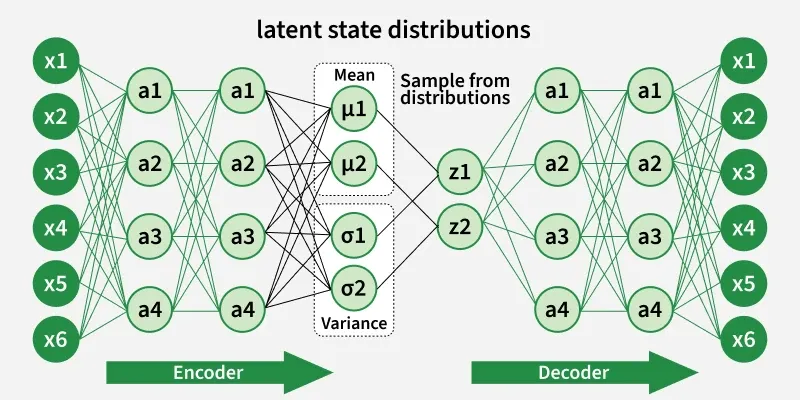


## Applications
Here are some common applications:

* Image Generation: Creates new realistic images by sampling from learned latent distributions.
* Anomaly Detection: Identifies anomalies by measuring how well input data is reconstructed.
* Dimensionality Reduction: Produces low-dimensional latent spaces useful for visualization and clustering.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.datasets import fashion_mnist

(x_train, _), (x_test, _) = fashion_mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train_cnn = x_train.reshape(-1, 28, 28, 1)
x_test_cnn = x_test.reshape(-1, 28, 28, 1)

latent_dim = 2
n = 10

encoder_inputs = tf.keras.Input(shape=(28, 28, 1))
x = tf.keras.layers.Conv2D(32, 3, activation='relu',
                           strides=2, padding='same')(encoder_inputs)
x = tf.keras.layers.Conv2D(64, 3, activation='relu',
                           strides=2, padding='same')(x)
x = tf.keras.layers.Flatten()(x)
x = tf.keras.layers.Dense(16, activation='relu')(x)
z_mean = tf.keras.layers.Dense(latent_dim)(x)
z_log_var = tf.keras.layers.Dense(latent_dim)(x)


def sampling(args):
    z_mean, z_log_var = args
    batch = tf.shape(z_mean)[0]
    dim = tf.shape(z_mean)[1]
    epsilon = tf.random.normal(shape=(batch, dim))
    return z_mean + tf.exp(0.5 * z_log_var) * epsilon


z = tf.keras.layers.Lambda(sampling)([z_mean, z_log_var])

encoder = tf.keras.Model(
    encoder_inputs, [z_mean, z_log_var, z], name='encoder')

latent_inputs = tf.keras.Input(shape=(latent_dim,))
x = tf.keras.layers.Dense(7 * 7 * 64, activation='relu')(latent_inputs)
x = tf.keras.layers.Reshape((7, 7, 64))(x)
x = tf.keras.layers.Conv2DTranspose(
    64, 3, strides=2, padding='same', activation='relu')(x)
x = tf.keras.layers.Conv2DTranspose(
    32, 3, strides=2, padding='same', activation='relu')(x)
decoder_outputs = tf.keras.layers.Conv2DTranspose(
    1, 3, padding='same', activation='sigmoid')(x)

decoder = tf.keras.Model(latent_inputs, decoder_outputs, name='decoder')

outputs = decoder(z)


class VAELossLayer(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super(VAELossLayer, self).__init__(**kwargs)

    def call(self, inputs):
        x, x_decoded, z_mean, z_log_var = inputs

        reconstruction_loss = tf.keras.losses.binary_crossentropy(
            K.flatten(x), K.flatten(x_decoded)
        )
        reconstruction_loss *= 28 * 28

        kl_loss = 1 + z_log_var - K.square(z_mean) - K.exp(z_log_var)
        kl_loss = K.sum(kl_loss, axis=-1)
        kl_loss *= -0.5

        total_loss = K.mean(reconstruction_loss + kl_loss)
        self.add_loss(total_loss)
        return x_decoded


outputs_with_loss = VAELossLayer()(
    [encoder_inputs, outputs, z_mean, z_log_var])

vae = tf.keras.Model(encoder_inputs, outputs_with_loss, name='vae_with_loss')

vae.compile(optimizer='adam')

vae.fit(x_train_cnn, epochs=50, batch_size=256,
        validation_data=(x_test_cnn, None))

decoded_imgs = vae.predict(x_test_cnn)

plt.figure(figsize=(20, 4))
for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test_cnn[i].reshape(28, 28), cmap='gray')
    ax.axis('off')

    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    ax.axis('off')
plt.show()